In [3]:
import numpy as np
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

# 1. Charger les données

La première étape est de charger les données de l'Assemblée nationale. Celles-ci se trouvent dans le dossier data/ de ce repo. On charge d'un côté les données de vote, et de l'autre celles des députés.

## 1.1. Données de vote

In [ ]:
path = "./data/scrutins/"

votes = []
for leg in [15,16,17]:
    print(f"Reading votes for legislature {leg}...")
    folderpath = f"{path}scrutins_{leg}/json/"
    # read all json file and put them in "votes"
    for filename in tqdm(os.listdir(folderpath)):
        if filename.endswith(".json"):
            with open(os.path.join(folderpath, filename), "r", encoding="utf-8") as f:
                votes.append(json.load(f))

Reading votes for legislature 15...


100%|██████████| 4417/4417 [00:01<00:00, 3016.96it/s]


Reading votes for legislature 16...


100%|██████████| 4106/4106 [00:01<00:00, 2524.50it/s]


Reading votes for legislature 17...


100%|██████████| 8434/8434 [00:03<00:00, 2199.45it/s]


## 1.2. Informations sur les députés

In [5]:
path = "./data/acteur/"

codeDeputes = {}
for filename in tqdm(os.listdir(path)):
    if filename.endswith(".json"):
        with open(os.path.join(path, filename), "r", encoding="utf-8") as f:
            json_data = json.load(f)["acteur"]
            etatCivil = json_data["etatCivil"]["ident"]
            nom = etatCivil["prenom"] + " " + etatCivil["nom"]
            codeDeputes[filename.split(".")[0]] = nom

100%|██████████| 577/577 [00:05<00:00, 100.50it/s]


## 1.3. Code des groupes politiques

In [6]:
code_groupes = {
    "PO845401": "RN",
    "PO845407": "EPR",
    "PO845413": "LFI",
    "PO845419": "PS",
    "PO845425": "DR",
    "PO845439": "Ecolo",
    "PO845454": "MoDem",
    "PO845470": "Horizons",
    "PO845485": "LIOT",
    "PO845514": "GDR",
    "PO872880": "UDR",
}

## 1.4. La proportion de scrutins publics ordinaires (SPO)

In [7]:
count, total = 0, 0
for vote in votes:
    v = vote["scrutin"]
    codeTypeVote = v["typeVote"]["codeTypeVote"]
    if codeTypeVote == "SPO":
        count += 1
    total += 1

print(f"Proportion of SPO votes: {count/total:.2%} ({count}/{total})")

Proportion of SPO votes: 98.25% (16661/16957)


# 2. Les délégations de vote

On va maintenant s'intéresser à la distribution dans le temps de ces délégations. Pour cela, on calcule pour chaque scrutin public ordinaire (SPO), les informations sur le nombre de vote et le nombre de délégation.

In [8]:
resultatDelegations = []

for vote in votes:
    v = vote["scrutin"]
    uid = v['uid']
    dateScrutin = v["dateScrutin"]
    codeTypeVote = v["typeVote"]["codeTypeVote"]
    legislature = v["legislature"]
    if codeTypeVote != "SPO":
        continue
    delegations = 0
    totalVotes = 0
    decompteGroupes = v["ventilationVotes"]['organe']['groupes']['groupe']
    for groupe in decompteGroupes:
        decompte = groupe['vote']['decompteVoix']
        n_vote = {"pours": decompte['pour'], "contres": decompte['contre']}
        decompteNominatif = groupe['vote']['decompteNominatif']
        for position in ['pours', 'contres']:
            if n_vote[position] == '0':
                continue
            elif n_vote[position] == '1':
                listeVotants = [decompteNominatif[position]['votant']]
            else:
                listeVotants = decompteNominatif[position]['votant']
            totalVotes += len(listeVotants)
            
            delegations += sum([1 for votant in listeVotants if votant['parDelegation'] == 'true'])
    resultatDelegations.append({
        'id': uid,
        "dateScrutin": dateScrutin,
        "delegations": delegations,
        "totalVotes": totalVotes,
        "legislature": legislature
    })



## 2.1. Proportion moyenne de délégations selon le mois

On calcule tout d'abord la proportion moyenne de délégations de vote par scrutin chaque mois

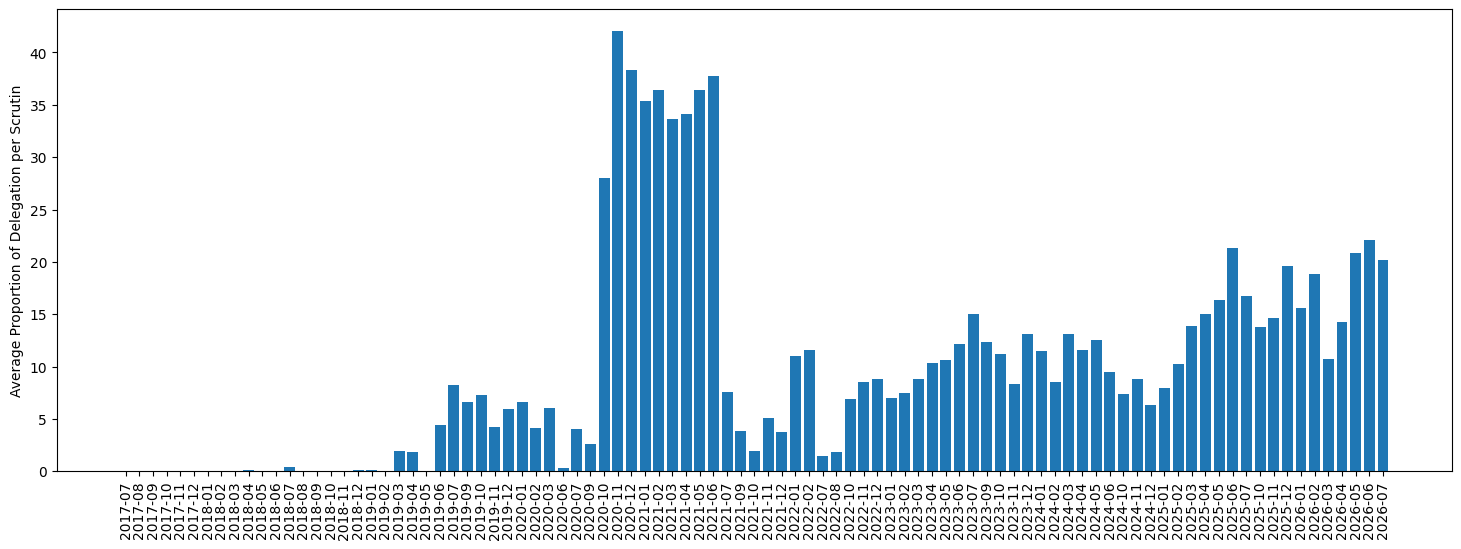

labels: ['2017-07', '2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-09', '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-06', '2020-07', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-07', '2022-08', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '

In [9]:
# calculer la moyenne par mois du nombre de delegation par scrutin, et la moyenne de la proportion par scrutin

monthsDelegations = {}
for result in resultatDelegations:
    dateScrutin = result["dateScrutin"]
    month = dateScrutin[:7]  # YYYY-MM
    if month not in monthsDelegations:
        monthsDelegations[month] = {"count": 0, "prop":0}
    monthsDelegations[month]["prop"] += result["delegations"] / result["totalVotes"] if result["totalVotes"] > 0 else 0
    monthsDelegations[month]["count"] += 1

months = sorted(monthsDelegations.keys())

fig = plt.figure(figsize=(18, 6))
avgProportion = [100*monthsDelegations[month]["prop"] / monthsDelegations[month]["count"] for month in months]
plt.bar(months, avgProportion, label="Average Proportion of Delegation per Scrutin")
plt.xticks(rotation=90)
plt.ylabel("Average Proportion of Delegation per Scrutin")
plt.show()

print("labels:", months)
print("data:", avgProportion)
print()

## 2.2. Proportion moyenne de délégations selon l'année

Notez que pour les années, on ignore la période "covid" entre octobre 2020 et juin 2021

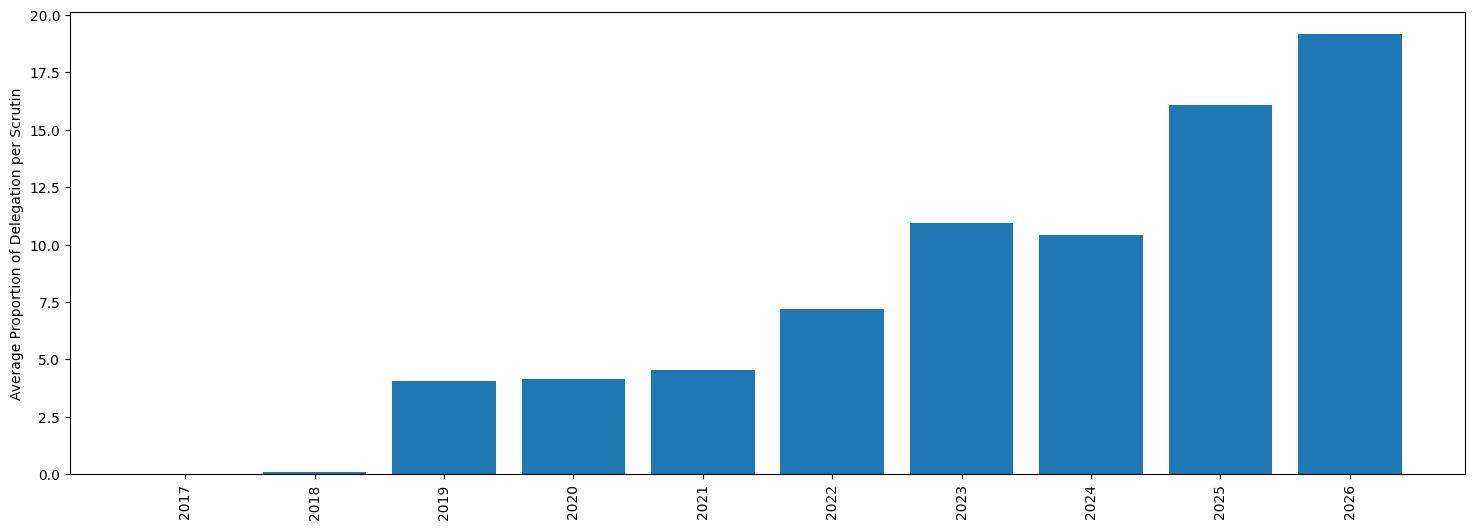

labels: ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
data: [0.0, 0.08250639688533072, 4.039191090031081, 4.147693518102742, 4.547959569457342, 7.190858601645747, 10.95799661544447, 10.412636203071946, 16.06550023314509, 19.170005490525227]



In [10]:

yearDelegations = {}
for result in resultatDelegations:
    dateScrutin = result["dateScrutin"]
    year = dateScrutin[:4]  # YYYY
    # ignorer si entre octobre 2020 et juin 2021
    if dateScrutin >= "2020-10-01" and dateScrutin <= "2021-06-30":
        continue
    if year not in yearDelegations:
        yearDelegations[year] = {"count": 0, "prop":0}
    yearDelegations[year]["prop"] += result["delegations"] / result["totalVotes"] if result["totalVotes"] > 0 else 0
    yearDelegations[year]["count"] += 1

years = sorted(yearDelegations.keys())

fig = plt.figure(figsize=(18, 6))
avgProportion = [yearDelegations[year]["prop"]*100 / yearDelegations[year]["count"] for year in years]
plt.bar(years, avgProportion, label="Average Proportion of Delegation per Scrutin")
plt.xticks(rotation=90)
plt.ylabel("Average Proportion of Delegation per Scrutin")
plt.show()

print("labels:", years)
print("data:", avgProportion)
print()

## 2.3. Journées avec les plus grandes proportions de délégations

On affiche quelques journées avec de grandes proportions de délégations

In [11]:

dayDelegations = {}
for result in resultatDelegations:
    dateScrutin = result["dateScrutin"]
    day = dateScrutin[:10]  # YYYY-mm-dd
    year = dateScrutin[:4]  # YYYY
    if year not in ["2026", "2025"]:
        continue

    if day not in dayDelegations:
        dayDelegations[day] = {"count": 0, "prop":0}
    dayDelegations[day]["prop"] += result["delegations"] / result["totalVotes"] if result["totalVotes"] > 0 else 0
    dayDelegations[day]["count"] += 1

# TOP 5 days with highest average proportion of delegation per scrutin + nb of scrutins that day

topDays = sorted(dayDelegations.items(), key=lambda x: x[1]["prop"] / x[1]["count"], reverse=True)[:5]
for day, data in topDays:
    avgProp = data["prop"] / data["count"]
    print(f"{day}: {avgProp:.2%} ({data['count']} scrutins)")
    # scrutin with most delegation this day
    mostdelegation = max([result for result in resultatDelegations if result["dateScrutin"][:10] == day], key=lambda x: x["delegations"]/x["totalVotes"] if x["totalVotes"] > 0 else 0)
    print(f"  Scrutin with most delegation: {mostdelegation['id']} ({mostdelegation['delegations']} delegations, {mostdelegation['totalVotes']} total votes, {mostdelegation['delegations']/mostdelegation['totalVotes']:.2%} proportion)")

2026-06-26: 35.47% (149 scrutins)
  Scrutin with most delegation: VTANR5L17V7701 (27 delegations, 62 total votes, 43.55% proportion)
2026-02-27: 34.51% (44 scrutins)
  Scrutin with most delegation: VTANR5L17V5785 (10 delegations, 24 total votes, 41.67% proportion)
2025-06-13: 31.33% (140 scrutins)
  Scrutin with most delegation: VTANR5L17V2421 (16 delegations, 43 total votes, 37.21% proportion)
2026-02-20: 30.15% (48 scrutins)
  Scrutin with most delegation: VTANR5L17V5585 (29 delegations, 84 total votes, 34.52% proportion)
2025-12-18: 28.41% (113 scrutins)
  Scrutin with most delegation: VTANR5L17V4894 (15 delegations, 42 total votes, 35.71% proportion)


## 2.4. Proportion de vote par délégation selon le jour de la semaine

on ne garde que la 17e legislature

In [12]:

dictDays = {}
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
for result in resultatDelegations:
    dateScrutin = result["dateScrutin"]
    year = dateScrutin[:4]  # YYYY
    dayOfWeek = days[pd.to_datetime(dateScrutin).dayofweek]
    legislature = result["legislature"]
    if legislature != "17":
        continue
    # print(dateScrutin, dayOfWeek)
    if dayOfWeek not in dictDays:
        dictDays[dayOfWeek] = {"count": 0, "prop":0, "vote":0}
    dictDays[dayOfWeek]["prop"] += result["delegations"] / result["totalVotes"] if result["totalVotes"] > 0 else 0
    dictDays[dayOfWeek]["vote"] += result["delegations"]
    dictDays[dayOfWeek]["count"] += 1


for dayOfWeek, data in dictDays.items():
    avgProp = data["prop"] / data["count"]
    print(f"{dayOfWeek}: {avgProp:.2%} ({data['count']} scrutins)")
    print(f"{dayOfWeek}: {data['vote']/data['count']} votes")


print("labels:",days)
print("data:",[dictDays[day]["prop"]*100 / dictDays[day]["count"] for day in days])
print()

Tuesday: 9.70% (959 scrutins)
Tuesday: 16.6444212721585 votes
Friday: 24.26% (1719 scrutins)
Friday: 24.634671320535194 votes
Thursday: 16.99% (2432 scrutins)
Thursday: 19.58511513157895 votes
Monday: 14.68% (1222 scrutins)
Monday: 17.42225859247136 votes
Wednesday: 13.64% (1591 scrutins)
Wednesday: 18.9120050282841 votes
Saturday: 20.17% (358 scrutins)
Saturday: 27.59776536312849 votes
Sunday: 22.10% (58 scrutins)
Sunday: 38.56896551724138 votes
labels: ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data: [14.680373170744454, 9.701909273491882, 13.636091359300854, 16.991419127728157, 24.261832049309863, 20.172662880013114, 22.097155053889992]



## 2.5. Délégations selon le groupe

On s'intéresse maintenant aux différences d'habitude de délégations de vote entre les groupes de l'Assemblée. On regarde aussi la proportion de députés qui votent à chaque scrutin (i.e., le taux de présence).

In [13]:
resultatDelegationsGroupes = {}


for vote in votes:
    v = vote["scrutin"]
    uid = v['uid']
    dateScrutin = v["dateScrutin"]
    codeTypeVote = v["typeVote"]["codeTypeVote"]
    legislature = v["legislature"]

    if legislature != '17':
        continue
    if codeTypeVote != "SPO":
        continue
    decompteGroupes = v["ventilationVotes"]['organe']['groupes']['groupe']
    for groupe in decompteGroupes:
        delegations = 0
        totalVotes = 0
        decompte = groupe['vote']['decompteVoix']
        groupeId = groupe['organeRef'] 
        nombreMembres = groupe['nombreMembresGroupe']
        if groupeId not in resultatDelegationsGroupes:
            resultatDelegationsGroupes[groupeId] = []
        n_vote = {"pours": decompte['pour'], "contres": decompte['contre']}
        decompteNominatif = groupe['vote']['decompteNominatif']
        for position in ['pours', 'contres']:
            if n_vote[position] == '0':
                continue
            elif n_vote[position] == '1':
                listeVotants = [decompteNominatif[position]['votant']]
            else:
                listeVotants = decompteNominatif[position]['votant']
            totalVotes += len(listeVotants)
            
            delegations += sum([1 for votant in listeVotants if votant['parDelegation'] == 'true'])
        if totalVotes > 0:
            resultatDelegationsGroupes[groupeId].append({
                'id': uid,
                "dateScrutin": dateScrutin,
                "delegations": delegations,
                "totalVotes": totalVotes,
                "totalMember": int(nombreMembres)
            })


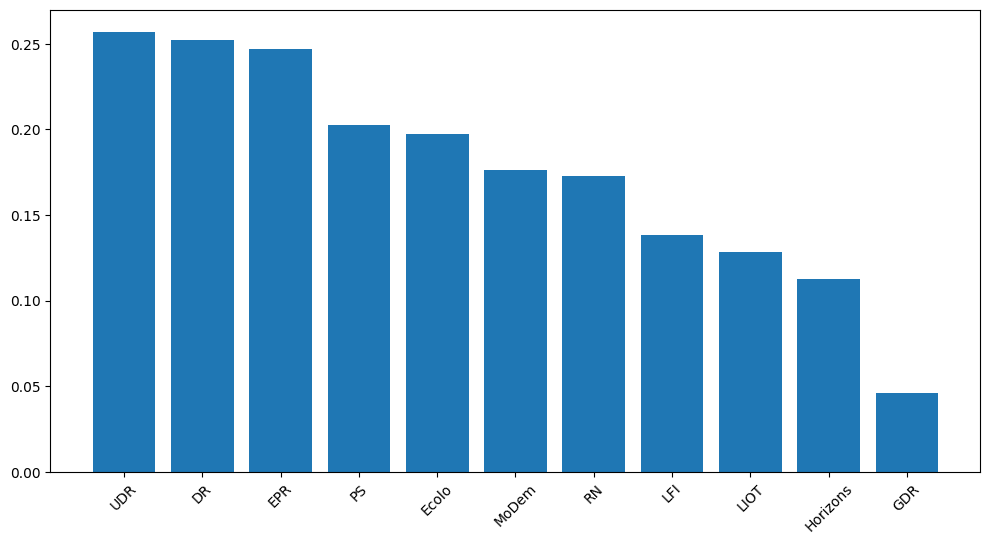

labels: ['UDR', 'DR', 'EPR', 'PS', 'Ecolo', 'MoDem', 'RN', 'LFI', 'LIOT', 'Horizons', 'GDR']
data: [25.70892610607268, 25.254979989274283, 24.679998433261645, 20.270977580402434, 19.707863562004828, 17.641288509554403, 17.25814154037553, 13.824384137108051, 12.824646638061354, 11.278596390591753, 4.624177066925156]


In [14]:

groupesDict = {}
for groupeId in code_groupes.keys():
    results = resultatDelegationsGroupes.get(groupeId, [])
    count = 0
    propSum = 0
    for result in results:
        dateScrutin = result["dateScrutin"]
        year = dateScrutin[:4]
        if year not in ["2026"]:
            continue
        prop = result["delegations"] / result["totalVotes"] if result["totalVotes"] > 0 else 0
        count += 1
        propSum += prop

    if count > 0:
        groupesDict[groupeId] = {"count": count, "avgProp": propSum / count}

groupesDict_sorted = sorted(groupesDict.items(), key=lambda x: x[1]["avgProp"], reverse=True)

plt.figure(figsize=(12, 6))
plt.bar([code_groupes[groupeId] for groupeId, _ in groupesDict_sorted], [data["avgProp"] for _, data in groupesDict_sorted])
plt.xticks(rotation=45)
plt.show()

print("labels:", [code_groupes[groupeId] for groupeId, _ in groupesDict_sorted])
print("data:", [data["avgProp"]*100 for _, data in groupesDict_sorted])

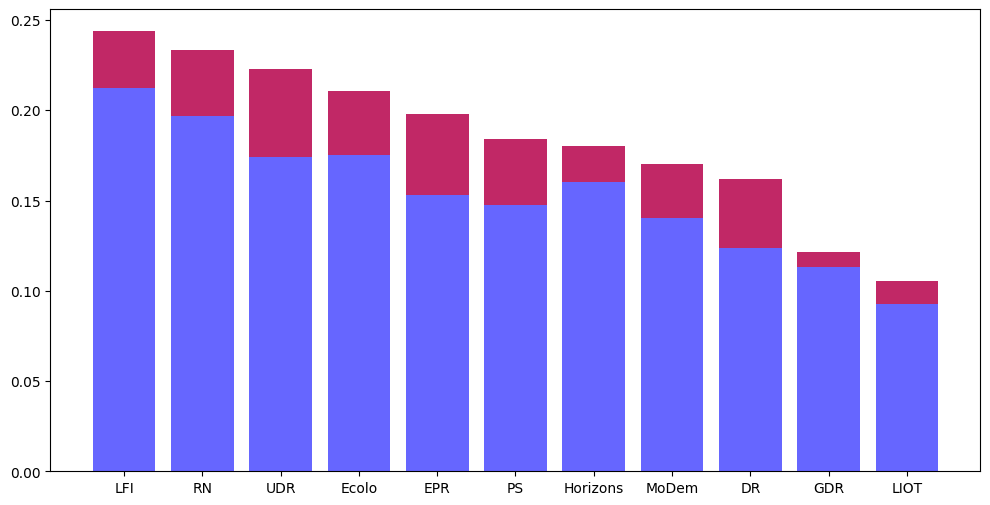

labels: ['LFI', 'RN', 'UDR', 'Ecolo', 'EPR', 'PS', 'Horizons', 'MoDem', 'DR', 'GDR', 'LIOT']
data1: [21.20640252084096, 19.669749005931656, 17.427065587734646, 17.507846631862645, 15.303820166836315, 14.751783035210595, 16.037226244726327, 14.034628180455455, 12.368792852905381, 11.305692760565137, 9.257096658282244]
data2: [3.1692305028697714, 3.6768219796504416, 4.86819195310167, 3.540053309780375, 4.493133830529834, 3.6697337605707765, 1.9939968891164408, 3.0122771159227777, 3.8147224857733866, 0.8157461457865562, 1.258896432601459]



In [15]:
groupesDict = {}
for groupeId in code_groupes.keys():
    results = resultatDelegationsGroupes.get(groupeId, [])

    count = 0
    voteSum = 0
    delegSum = 0
    for result in results:
        dateScrutin = result["dateScrutin"]
        year = dateScrutin[:4]
        if year not in ["2026"]:
            continue
        voteSum += result["totalVotes"]/result["totalMember"] if result["totalMember"] > 0 else 0
        delegSum += result["delegations"]/result["totalMember"] if result["totalMember"] > 0 else 0
        count += 1


    if count > 0:
        groupesDict[groupeId] = {"count": count, "avgVote": voteSum / count, "avgDeleg": delegSum / count}


groupesDict_sorted = sorted(groupesDict.items(), key=lambda x: x[1]["avgVote"], reverse=True)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar([code_groupes[groupeId] for groupeId, _ in groupesDict_sorted], [data["avgVote"] for _, data in groupesDict_sorted], color='b', alpha=0.6, label="Average Total Votes per Member")
ax1.bar([code_groupes[groupeId] for groupeId, _ in groupesDict_sorted], [data["avgDeleg"] for _, data in groupesDict_sorted], bottom=[data["avgVote"]-data["avgDeleg"] for _, data in groupesDict_sorted], color='r', alpha=0.6, label="Average Delegations per Member")
plt.show()
print("labels:",[code_groupes[groupeId] for groupeId, _ in groupesDict_sorted])
print("data1:",[(data["avgVote"]-data["avgDeleg"])*100 for _, data in groupesDict_sorted])
print("data2:", [data["avgDeleg"]*100 for _, data in groupesDict_sorted])
print()

# 3. A qui profitent les délégations ?

On veut maintenant voir quand des délégations changent le résultat du scrutin.

In [16]:

votes_delegations = {}
for vote in votes:
    v = vote["scrutin"]
    uid = v['uid']
    dateScrutin = v["dateScrutin"]
    codeTypeVote = v["typeVote"]["codeTypeVote"]
    legislature = v["legislature"]
    if codeTypeVote != "SPO":
        continue
    if legislature != '17':
        continue
    delegations = {"pours": 0, "contres": 0}
    totalVotes = {"pours": 0, "contres": 0}
    decompteGroupes = v["ventilationVotes"]['organe']['groupes']['groupe']
    positionsMajoritaires = {}
    for groupe in decompteGroupes:
        decompte = groupe['vote']['decompteVoix']
        n_vote = {"pours": decompte['pour'], "contres": decompte['contre']}
        if n_vote['pours'] > n_vote['contres']:
            positionsMajoritaires[groupe['organeRef']] = 'pours'
        elif n_vote['contres'] > n_vote['pours']:
            positionsMajoritaires[groupe['organeRef']] = 'contres'
        else:
            positionsMajoritaires[groupe['organeRef']] = 'egalite'
        decompteNominatif = groupe['vote']['decompteNominatif']
        for position in ['pours', 'contres']:
            if n_vote[position] == '0':
                continue
            elif n_vote[position] == '1':
                listeVotants = [decompteNominatif[position]['votant']]
            else:
                listeVotants = decompteNominatif[position]['votant']            
            delegations[position] += sum([1 for votant in listeVotants if votant['parDelegation'] == 'true'])
            totalVotes[position] += len(listeVotants)
    votes_delegations[uid] = {
        "dateScrutin": dateScrutin,
        "delegations": delegations,
        "totalVotes": totalVotes,
        "positionsMajoritaires": positionsMajoritaires
    }


## 3.1. Proportion de scrutins avec changement de résultat 

On calcule la proportion de scrutins concernés

In [17]:
# compte le nombre de votes ou le resultat change avec ou sans les delegations

uid_with_change = []
c = 0
for uid, data in votes_delegations.items():
    delegations = data["delegations"]
    totalVotes = data["totalVotes"]
    dateScrutin = data["dateScrutin"]
    if totalVotes["pours"] + totalVotes["contres"] == 0:
        continue
    
    result_with_delegations = "pours" if totalVotes["pours"] > totalVotes["contres"] else "contres"
    result_without_delegations = "pours" if (totalVotes["pours"] - delegations["pours"]) > (totalVotes["contres"] - delegations["contres"]) else "contres"
    if result_with_delegations != result_without_delegations:
        c += 1
        uid_with_change.append(uid)

print(c/len(votes_delegations))
print(c)

0.019786545149298475
165


## 3.2. Evolution au cours des années

On regarde le nombre chaque année

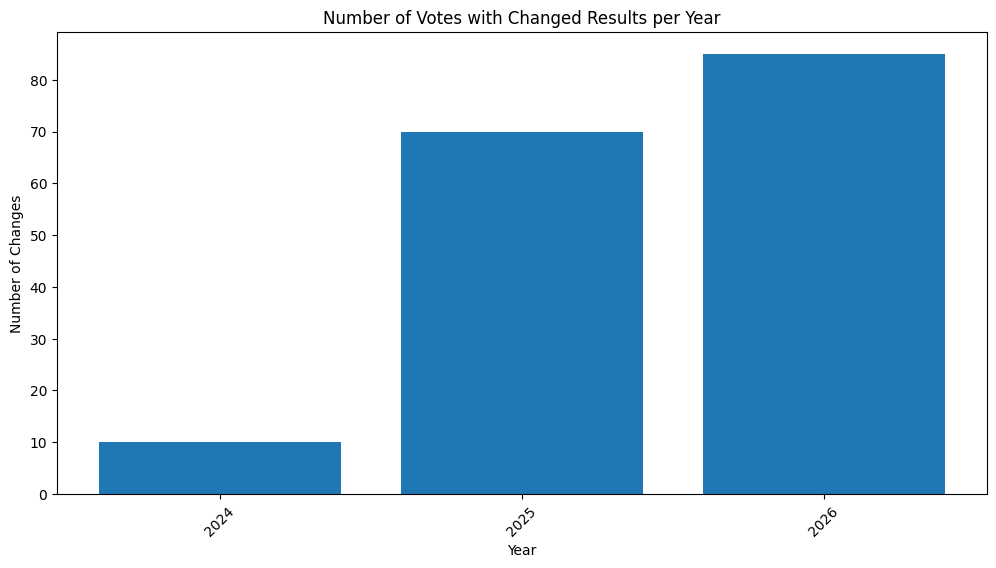

['2024', '2025', '2026']
[10, 70, 85]


In [18]:

change_per_year = {}
for vote in votes:
    v = vote["scrutin"]
    uid = v['uid']
    dateScrutin = v["dateScrutin"]
    year = dateScrutin[:4]  # YYYY
    legislature = v["legislature"]
    if legislature != '17':
        continue
    codeTypeVote = v["typeVote"]["codeTypeVote"]
    if codeTypeVote != "SPO":
        continue
    if year not in change_per_year:
        change_per_year[year] = 0
    if uid in uid_with_change:
        change_per_year[year] += 1

# plot

plt.figure(figsize=(12, 6))
years = sorted(change_per_year.keys())
values = [change_per_year[year] for year in years]
plt.bar(years, values)
plt.xlabel("Year")
plt.ylabel("Number of Changes")
plt.title("Number of Votes with Changed Results per Year")
plt.xticks(rotation=45)
plt.show()
print(years)
print(values)

## 3.3. Le 10 juillet

In [19]:
changes = 0
c = 0
for vote in votes:
    v = vote["scrutin"]
    uid = v['uid']
    dateScrutin = v["dateScrutin"]
    if dateScrutin == "2026-07-10":
        c += 1
        if uid in uid_with_change:
            changes += 1
print(changes, c, changes/c)

26 111 0.23423423423423423


## 3.4. Avantage selon le groupe

In [20]:
# check which organeRef is more advantaged by changes due to delegations

advantageDict = {}
count2026 = 0
for uid, data in votes_delegations.items():
    delegations = data["delegations"]
    dateScrutin = data["dateScrutin"]
    totalVotes = data["totalVotes"]
    positionsMajoritaires = data["positionsMajoritaires"]
    if dateScrutin < "2026-01-01":
        continue
    if totalVotes["pours"] + totalVotes["contres"] == 0:
        continue
    result_with_delegations = "pours" if totalVotes["pours"] > totalVotes["contres"] else "contres"
    result_without_delegations = "pours" if (totalVotes["pours"] - delegations["pours"]) > (totalVotes["contres"] - delegations["contres"]) else "contres"
    if result_with_delegations != result_without_delegations:
        count2026 += 1
        for organeRef, position in positionsMajoritaires.items():
            if organeRef not in advantageDict:
                advantageDict[organeRef] = {"plus": 0, "moins": 0}
            if position == result_with_delegations:
                advantageDict[organeRef]["plus"] += 1
            elif position != "egalite":
                advantageDict[organeRef]["moins"] += 1

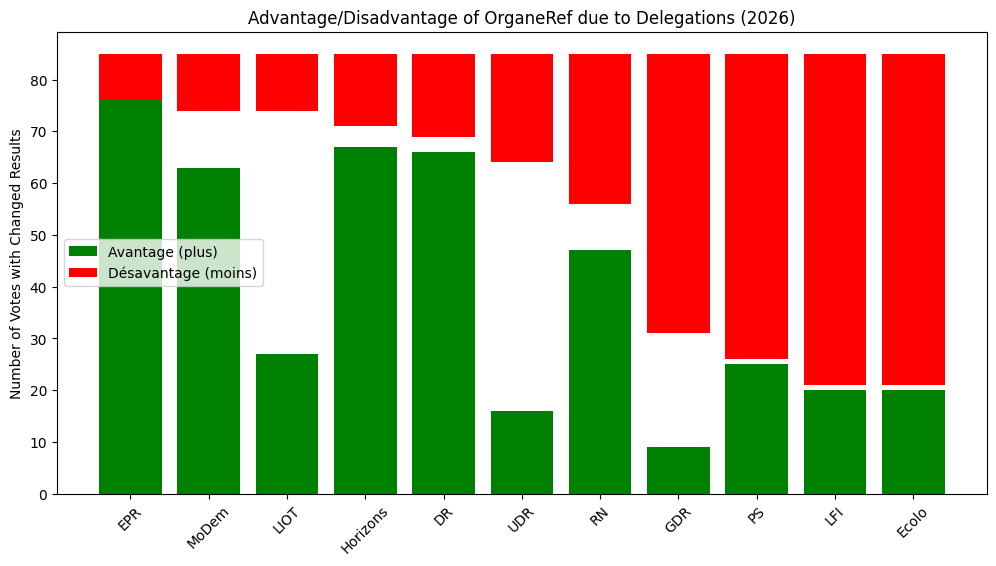

['EPR', 'MoDem', 'LIOT', 'Horizons', 'DR', 'UDR', 'RN', 'GDR', 'PS', 'LFI', 'Ecolo']
[76, 63, 27, 67, 66, 16, 47, 9, 25, 20, 20]
[9, 11, 11, 14, 16, 21, 29, 54, 59, 64, 64]
[0, 11, 47, 4, 3, 48, 9, 22, 1, 1, 1]


In [21]:
# plot le "avantage" (plus) et "desavantage" (moins) pour chaque organeRef

plt.figure(figsize=(12, 6))
organeRefs = list(code_groupes.keys())
plus_values = [advantageDict.get(organeRef, {}).get("plus", 0) for organeRef in organeRefs]
moins_values = [advantageDict.get(organeRef, {}).get("moins", 0) for organeRef in organeRefs]
# trier selon plus_values
sorted_indices = np.argsort(moins_values)
organeRefs = [organeRefs[i] for i in sorted_indices]
x = np.arange(len(organeRefs))
plt.bar(x, [plus_values[i] for i in sorted_indices], label="Avantage (plus)", color='g')
plt.bar(x, [moins_values[i] for i in sorted_indices], bottom=[count2026 - moins_values[i] for i in sorted_indices], label="Désavantage (moins)", color='r')
plt.xticks(x, [code_groupes[organeRef] for organeRef in organeRefs], rotation=45)
plt.ylabel("Number of Votes with Changed Results")
plt.title("Advantage/Disadvantage of OrganeRef due to Delegations (2026)")
plt.legend()
plt.show()

print([code_groupes[organeRef] for organeRef in organeRefs])
print([plus_values[i] for i in sorted_indices])
print([moins_values[i] for i in sorted_indices])
print([count2026 - moins_values[i] - plus_values[i] for i in sorted_indices])

# 4. Les députés absents

Intéressons-nous maintenant aux députés qui déléguent

In [22]:
dicoDeleguants = {}

allvotes = 0

for vote in votes:
    v = vote["scrutin"]
    uid = v['uid']
    legislature = v["legislature"]
    dateScrutin = v["dateScrutin"]
    if dateScrutin < "2026-01-01":
        continue
    decompteGroupes = v["ventilationVotes"]['organe']['groupes']['groupe']
    allvotes += 1
    for groupe in decompteGroupes:
        decompte = groupe['vote']['decompteVoix']
        n_vote = {"pours": decompte['pour'], "contres": decompte['contre']}
        decompteNominatif = groupe['vote']['decompteNominatif']
        for position in ['pours', 'contres']:
            if n_vote[position] == '0':
                continue
            elif n_vote[position] == '1':
                listeVotants = [decompteNominatif[position]['votant']]
            else:
                listeVotants = decompteNominatif[position]['votant']
            for votant in listeVotants:
                acteurRef=  votant['acteurRef']
                if acteurRef not in dicoDeleguants:
                    dicoDeleguants[acteurRef] = {"delegations": 0, "totalVotes": 0}
                dicoDeleguants[acteurRef]["totalVotes"] += 1
                if votant['parDelegation'] == 'true':
                    dicoDeleguants[acteurRef]["delegations"] += 1

## 4.1. Les députés qui ont le plus voté en 2026

In [23]:
resultatDelegations = sorted(dicoDeleguants.items(), key=lambda x: x[1]["totalVotes"] if x[1]["totalVotes"] > 0 else 0, reverse=True)
k = 20
print(f"Top {k} votants le plus en 2026:")
for i in range(k):
    acteurRef, data = resultatDelegations[i]
    if data["totalVotes"] < 100:
        continue
    proportion = data["delegations"] / data["totalVotes"] if data["totalVotes"] > 0 else 0
    print(f"ActeurRef: {codeDeputes.get(acteurRef, acteurRef)}, Proportion de délégations: {proportion:.2%}, Delegations: {data['delegations']}, Total Votes: {data['totalVotes']}")


resultatDelegations = sorted(dicoDeleguants.items(), key=lambda x: x[1]["totalVotes"] if x[1]["totalVotes"] > 0 else 0, reverse=True)

print([codeDeputes.get(acteurRef, acteurRef) for acteurRef, data in resultatDelegations if data["totalVotes"] >= 100][:20])
print([data["delegations"] for acteurRef, data in resultatDelegations if data["totalVotes"] >= 100][:20])
print([data["totalVotes"]-data["delegations"] for acteurRef, data in resultatDelegations if data["totalVotes"] >= 100][:20])
print()

Top 20 votants le plus en 2026:
ActeurRef: Anthony Brosse, Proportion de délégations: 99.43%, Delegations: 2617, Total Votes: 2632
ActeurRef: Marine Hamelet, Proportion de délégations: 41.54%, Delegations: 992, Total Votes: 2388
ActeurRef: Valérie Bazin-Malgras, Proportion de délégations: 97.00%, Delegations: 2196, Total Votes: 2264
ActeurRef: Claire Marais-Beuil, Proportion de délégations: 2.15%, Delegations: 47, Total Votes: 2189
ActeurRef: David Magnier, Proportion de délégations: 0.10%, Delegations: 2, Total Votes: 1956
ActeurRef: Christine Loir, Proportion de délégations: 21.54%, Delegations: 417, Total Votes: 1936
ActeurRef: Sarah Legrain, Proportion de délégations: 96.44%, Delegations: 1760, Total Votes: 1825
ActeurRef: Anaïs Sabatini, Proportion de délégations: 82.35%, Delegations: 1488, Total Votes: 1807
ActeurRef: Lisette Pollet, Proportion de délégations: 0.00%, Delegations: 0, Total Votes: 1807
ActeurRef: Emmanuel Fernandes, Proportion de délégations: 19.99%, Delegations: 3

## 4.2. Des députés en missions

In [24]:
list_missions = ["PA608172", "PA719472", "PA795374", "PA607553", "PA721764", "PA719286", "PA719138", "PA720992", "PA643089", "PA795528", "PA793572", "PA795050", "PA719218", "PA606507", "PA722374", "PA712015", "PA721314", "PA794206"]

list_dates = ["2026-04-30","2026-04-30", "2026-04-10", "2026-04-10", "2026-04-10", "2026-04-02", "2026-04-02", "2026-03-03", "2026-03-11", "2026-03-11", "2026-03-11", "2026-02-04", "2026-02-04", "2026-01-19", "2026-01-13", "2026-01-15", "2026-01-05", "2025-12-01"]

max_date = []
min_date = []
for i in range(len(list_dates)):
    date = pd.to_datetime(list_dates[i])
    upper = date + pd.DateOffset(months=4)
    lower = date - pd.DateOffset(months=4)
    # convert to str
    max_date.append(upper.strftime("%Y-%m-%d"))
    min_date.append(lower.strftime("%Y-%m-%d"))

dict_res = {}
for code_dep in list_missions:
    dict_res[code_dep] = {"before": {"delegations": 0, "direct": 0, "total": 0}, "after": {"delegations": 0, "direct": 0, "total": 0}}

for vote in votes:
    v = vote["scrutin"]
    legislature = v["legislature"]
    dateScrutin = v["dateScrutin"]
    codeTypeVote = v["typeVote"]["codeTypeVote"]
    if codeTypeVote != "SPO":
        continue
    if legislature != '17':
        continue
    for acteurRef in list_missions:
        index = list_missions.index(acteurRef)
        date_mission = list_dates[index]
        min_date_mission = min_date[index]
        max_date_mission = max_date[index]
        if dateScrutin >= min_date_mission and dateScrutin <= date_mission:
            dict_res[acteurRef]["before"]["total"] += 1
        elif dateScrutin > date_mission and dateScrutin <= max_date_mission:
            dict_res[acteurRef]["after"]["total"] += 1
    for groupe in v["ventilationVotes"]['organe']['groupes']['groupe']:
        decompte = groupe['vote']['decompteVoix']
        n_vote = {"pours": decompte['pour'], "contres": decompte['contre']}
        decompteNominatif = groupe['vote']['decompteNominatif']
        for position in ['pours', 'contres']:
            if n_vote[position] == '0':
                continue
            elif n_vote[position] == '1':
                listeVotants = [decompteNominatif[position]['votant']]
            else:
                listeVotants = decompteNominatif[position]['votant']

            for votant in listeVotants:
                acteurRef=  votant['acteurRef']
                if acteurRef in list_missions:
                    index = list_missions.index(acteurRef)
                    date_mission = list_dates[index]
                    min_date_mission = min_date[index]
                    max_date_mission = max_date[index]
                    if dateScrutin >= min_date_mission and dateScrutin <= date_mission:
                        if votant['parDelegation'] == 'true':
                            dict_res[acteurRef]["before"]["delegations"] += 1
                        else:
                            dict_res[acteurRef]["before"]["direct"] += 1
                    elif dateScrutin > date_mission and dateScrutin <= max_date_mission:
                        if votant['parDelegation'] == 'true':
                            dict_res[acteurRef]["after"]["delegations"] += 1
                        else:
                            dict_res[acteurRef]["after"]["direct"] += 1


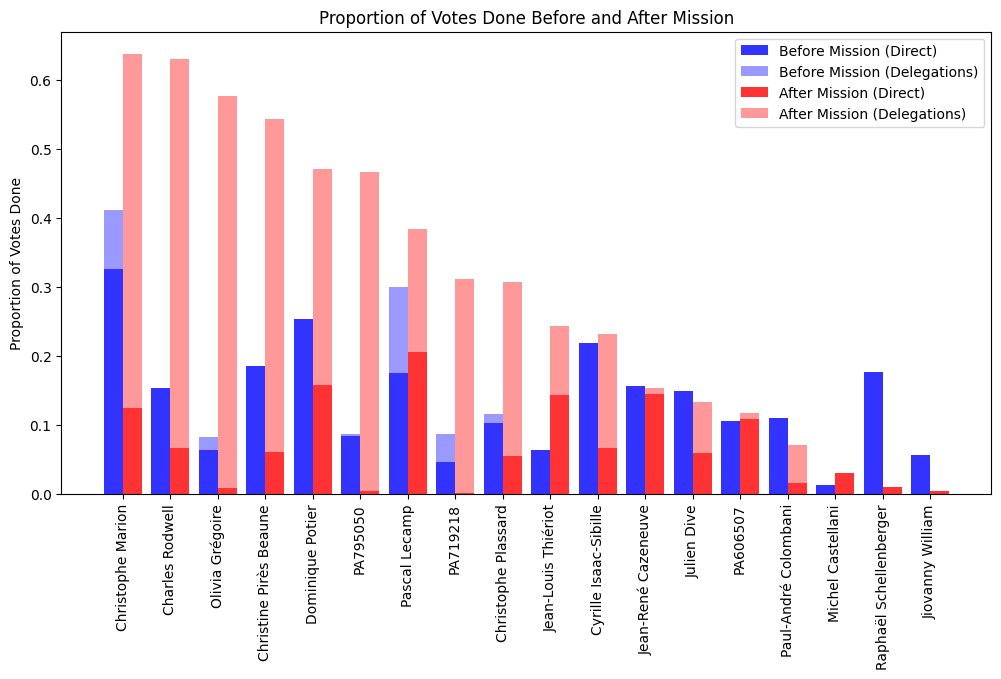

bar_before_direct =  [0.32608695652173914, 0.1539906103286385, 0.06272022551092318, 0.18456883509833585, 0.25299506694855534, 0.08385370205173952, 0.17477096546863988, 0.0463871543264942, 0.10234741784037558, 0.06291079812206572, 0.21875, 0.15658093797276854, 0.14886251236399603, 0.10534124629080119, 0.10933503836317135, 0.012148337595907928, 0.17684545937334042, 0.05671761866452132]
bar_before_delegations =  [0.08550724637681159, 0.0, 0.019732205778717406, 0.0, 0.0, 0.0026761819803746653, 0.12473572938689217, 0.03969669937555754, 0.013615023474178404, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
bar_after_direct =  [0.12412028150991683, 0.06630971993410215, 0.00881445570736007, 0.05990566037735849, 0.15777875716174528, 0.0039584364176150424, 0.20625826355222565, 0.0009896091044037606, 0.054777594728171335, 0.14332784184514002, 0.06634205721241632, 0.14481132075471698, 0.058403634003893576, 0.10901339829476249, 0.015539689206215875, 0.02981940361192776, 0.009420289855072464, 0.00374707

In [25]:
order = sorted(list_missions, key=lambda x: (dict_res[x]["after"]["direct"] + dict_res[x]["after"]["delegations"]) / dict_res[x]["after"]["total"] if dict_res[x]["after"]["total"] > 0 else 0, reverse=True)
plt.figure(figsize=(12, 6))
labels = [codeDeputes.get(code_dep, code_dep) for code_dep in order]
bar_before_direct = [(dict_res[code_dep]["before"]["direct"]) / dict_res[code_dep]["before"]["total"] if dict_res[code_dep]["before"]["total"] > 0 else 0 for code_dep in order]
bar_after_direct = [(dict_res[code_dep]["after"]["direct"]) / dict_res[code_dep]["after"]["total"] if dict_res[code_dep]["after"]["total"] > 0 else 0 for code_dep in order]
bar_before_delegations = [(dict_res[code_dep]["before"]["delegations"]) / dict_res[code_dep]["before"]["total"] if dict_res[code_dep]["before"]["total"] > 0 else 0 for code_dep in order]
bar_after_delegations = [(dict_res[code_dep]["after"]["delegations"]) / dict_res[code_dep]["after"]["total"] if dict_res[code_dep]["after"]["total"] > 0 else 0 for code_dep in order]
plt.bar([x-0.2 for x in range(len(labels))], bar_before_direct, label="Before Mission (Direct)", alpha=0.8, width=0.4, color='b')
plt.bar([x-0.2 for x in range(len(labels))], bar_before_delegations, bottom=bar_before_direct, label="Before Mission (Delegations)", alpha=0.4, width=0.4, color='b')
plt.bar([x+0.2 for x in range(len(labels))], bar_after_direct, label="After Mission (Direct)", alpha=0.8, width=0.4, color='r')
plt.bar([x+0.2 for x in range(len(labels))], bar_after_delegations, bottom=bar_after_direct, label="After Mission (Delegations)", alpha=0.4, width=0.4, color='r')
plt.xticks([x for x in range(len(labels))], labels, rotation=45)
plt.xticks(rotation=90)
plt.ylabel("Proportion of Votes Done")
plt.title("Proportion of Votes Done Before and After Mission")
plt.legend()
plt.show()
print("bar_before_direct = ", bar_before_direct)
print("bar_before_delegations = ", bar_before_delegations)
print("bar_after_direct = ", bar_after_direct)
print("bar_after_delegations = ", bar_after_delegations)
print("labels = ", labels)
print()

In [26]:
moyenne_avant = np.mean((dict_res[code_dep]["before"]["direct"]+dict_res[code_dep]["before"]["delegations"]) / dict_res[code_dep]["before"]["total"])
moyenne_apres = np.mean((dict_res[code_dep]["after"]["direct"]+dict_res[code_dep]["after"]["delegations"]) / dict_res[code_dep]["after"]["total"])
print(f"Moyenne du taux de participation totale AVANT: {moyenne_avant:.2%}")
print(f"Moyenne du taux de participation totale APRES: {moyenne_apres:.2%}")

# juste délégations AVANT et APRES
moyenne_delegations_avant = np.mean(dict_res[code_dep]["before"]["delegations"] / (dict_res[code_dep]["before"]["delegations"] + dict_res[code_dep]["before"]["direct"]))
moyenne_delegations_apres = np.mean(dict_res[code_dep]["after"]["delegations"] / (dict_res[code_dep]["after"]["delegations"] + dict_res[code_dep]["after"]["direct"]))
print(f"Moyenne du taux de délégations AVANT: {moyenne_delegations_avant:.2%}")
print(f"Moyenne du taux de délégations APRES: {moyenne_delegations_apres:.2%}")

Moyenne du taux de participation totale AVANT: 41.16%
Moyenne du taux de participation totale APRES: 63.85%
Moyenne du taux de délégations AVANT: 20.77%
Moyenne du taux de délégations APRES: 80.56%


## 4.3. Des absences qui posent questions

Ci-dessous, pour les députés cités dans l'article, avec les jours de délégation cités dans l'article, on peut donner le nombre de délégation chaque jour

In [41]:
def delegOfDay(acteurRef_param, day):
    print(f"Votes for {codeDeputes.get(acteurRef_param, acteurRef_param)} on {day}:")
    dico_votes = {}
    for vote in votes:
        v = vote["scrutin"]
        uid = v['uid']
        legislature = v["legislature"]
        dateScrutin = v["dateScrutin"]
        titre = v["titre"]
        if dateScrutin != day:
            continue
        seance = v["quantiemeJourSeance"]

        decompteGroupes = v["ventilationVotes"]['organe']['groupes']['groupe']
        for groupe in decompteGroupes:
                decompte = groupe['vote']['decompteVoix']
                n_vote = {"pours": decompte['pour'], "contres": decompte['contre'], "nonVotants": decompte['nonVotants']}
                decompteNominatif = groupe['vote']['decompteNominatif']
                for position in ['pours', 'contres', 'nonVotants']:
                    if n_vote[position] == '0':
                        continue
                    elif n_vote[position] == '1':
                        listeVotants = [decompteNominatif[position]['votant']]
                    else:
                        listeVotants = decompteNominatif[position]['votant']
                    for votant in listeVotants:
                        acteurRef=  votant['acteurRef']
                        if acteurRef != acteurRef_param:
                            continue
                        elif position != 'nonVotants':
                            if seance not in dico_votes:
                                dico_votes[seance] = [0,0]
                            if votant['parDelegation'] == 'true':
                                dico_votes[seance][0] += 1
                            else:
                                dico_votes[seance][1] += 1

    for seance, v in dico_votes.items():
        print(f"Seance {seance}: {v[0]} delegations, {v[1]} votes directs")
    print()
 

In [60]:
anthony_brosse = "PA794330"
angelique_ranc = "PA793230"
marine_hamelet = "PA795900"
brigitte_klinkert = "PA643184"
nathalie_carvalho = "PA795644"
corentin_le_fur = "PA840979"
charles_fournier = "PA793980"
valerie_bazin = "PA718884"
alexandre_allegret = "PA841067"
sarah_legrain = "PA791824"
edwige_diaz= "PA793928"
anais_sabatini = "PA794894"
tiffany_joncour = "PA841749"
delphine_lingemann = "PA794702"
christelle_minard = "PA643104"
charles_rodwell = "PA795528"
astrid_panosyan = "PA795050"
olivia_gregoire = "PA721764"

In [44]:
delegOfDay(christelle_minard, "2026-07-15")
delegOfDay(christelle_minard, "2026-07-16")
delegOfDay(christelle_minard, "2026-07-17")

Votes for Christelle Minard on 2026-07-15:
Seance 1: 2 delegations, 0 votes directs
Seance 2: 9 delegations, 0 votes directs

Votes for Christelle Minard on 2026-07-16:
Seance 1: 12 delegations, 0 votes directs
Seance 2: 21 delegations, 0 votes directs
Seance 3: 14 delegations, 0 votes directs

Votes for Christelle Minard on 2026-07-17:
Seance 1: 24 delegations, 0 votes directs
Seance 2: 5 delegations, 0 votes directs



### 4.3.1. Présents en circonscription

In [45]:
delegOfDay(angelique_ranc, "2026-05-26")
delegOfDay(angelique_ranc, "2026-07-08")
delegOfDay(marine_hamelet, "2026-06-26")

Votes for Angélique Ranc on 2026-05-26:
Seance 1: 5 delegations, 0 votes directs
Seance 2: 28 delegations, 0 votes directs

Votes for Angélique Ranc on 2026-07-08:
Seance 1: 48 delegations, 0 votes directs
Seance 2: 5 delegations, 0 votes directs

Votes for Marine Hamelet on 2026-06-26:
Seance 1: 47 delegations, 0 votes directs
Seance 2: 65 delegations, 0 votes directs
Seance 3: 29 delegations, 0 votes directs



In [46]:
delegOfDay(brigitte_klinkert, "2026-06-18")
delegOfDay(nathalie_carvalho, "2026-06-18")
delegOfDay(corentin_le_fur, "2026-06-18")
delegOfDay(anthony_brosse, "2026-06-18")
delegOfDay(charles_fournier, "2026-06-18")

Votes for Brigitte Klinkert on 2026-06-18:
Seance 1: 10 delegations, 0 votes directs
Seance 2: 2 delegations, 0 votes directs

Votes for Nathalie Da Conceicao Carvalho on 2026-06-18:
Seance 1: 9 delegations, 0 votes directs
Seance 2: 1 delegations, 0 votes directs

Votes for Corentin Le Fur on 2026-06-18:
Seance 1: 9 delegations, 0 votes directs
Seance 2: 2 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-06-18:
Seance 1: 11 delegations, 0 votes directs

Votes for Charles Fournier on 2026-06-18:
Seance 1: 10 delegations, 0 votes directs
Seance 2: 2 delegations, 0 votes directs



In [47]:
delegOfDay(valerie_bazin, "2026-05-29")

Votes for Valérie Bazin-Malgras on 2026-05-29:
Seance 1: 40 delegations, 0 votes directs
Seance 2: 50 delegations, 0 votes directs
Seance 3: 22 delegations, 0 votes directs



### 4.3.2. Dans les médias

In [49]:
delegOfDay(alexandre_allegret, "2025-12-18")
delegOfDay(sarah_legrain, "2026-06-17")
delegOfDay(edwige_diaz, "2026-05-06")
delegOfDay(edwige_diaz, "2026-02-24")

Votes for Alexandre Allegret-Pilot on 2025-12-18:
Seance 1: 10 delegations, 0 votes directs
Seance 2: 17 delegations, 0 votes directs
Seance 3: 0 delegations, 1 votes directs

Votes for Sarah Legrain on 2026-06-17:
Seance 1: 2 delegations, 0 votes directs
Seance 2: 6 delegations, 0 votes directs

Votes for Edwige Diaz on 2026-05-06:
Seance 1: 0 delegations, 11 votes directs
Seance 2: 27 delegations, 0 votes directs

Votes for Edwige Diaz on 2026-02-24:
Seance 1: 22 delegations, 0 votes directs
Seance 2: 8 delegations, 0 votes directs



### 4.3.3. A l'Assemblée mais pas dans l'hémicycle

In [51]:
delegOfDay(anais_sabatini, "2026-05-12")
delegOfDay(anais_sabatini, "2026-05-29")
delegOfDay(valerie_bazin, "2026-05-13")

Votes for Anaïs Sabatini on 2026-05-12:
Seance 2: 6 delegations, 0 votes directs
Seance 3: 17 delegations, 0 votes directs

Votes for Anaïs Sabatini on 2026-05-29:
Seance 1: 29 delegations, 0 votes directs
Seance 2: 38 delegations, 9 votes directs
Seance 3: 24 delegations, 0 votes directs

Votes for Valérie Bazin-Malgras on 2026-05-13:
Seance 1: 1 delegations, 0 votes directs
Seance 2: 53 delegations, 0 votes directs



In [52]:
delegOfDay(anthony_brosse, "2026-04-16")
delegOfDay(anthony_brosse, "2026-05-29")
delegOfDay(anthony_brosse, "2026-06-02")
delegOfDay(anthony_brosse, "2026-06-23")

Votes for Anthony Brosse on 2026-04-16:
Seance 1: 27 delegations, 0 votes directs
Seance 2: 12 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-05-29:
Seance 1: 40 delegations, 0 votes directs
Seance 2: 46 delegations, 0 votes directs
Seance 3: 25 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-06-02:
Seance 1: 3 delegations, 0 votes directs
Seance 2: 8 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-06-23:
Seance 1: 17 delegations, 0 votes directs
Seance 2: 22 delegations, 0 votes directs



### 4.3.4. Un député très actif

In [56]:
delegOfDay(anthony_brosse, "2026-05-20")
delegOfDay(anthony_brosse, "2026-05-22")
delegOfDay(anthony_brosse, "2026-05-27")
delegOfDay(anthony_brosse, "2026-05-28")

Votes for Anthony Brosse on 2026-05-20:
Seance 1: 11 delegations, 0 votes directs
Seance 2: 8 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-05-22:
Seance 1: 26 delegations, 0 votes directs
Seance 2: 8 delegations, 0 votes directs
Seance 3: 22 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-05-27:
Seance 1: 40 delegations, 0 votes directs
Seance 2: 19 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-05-28:
Seance 1: 10 delegations, 0 votes directs
Seance 2: 22 delegations, 0 votes directs
Seance 3: 12 delegations, 0 votes directs



In [57]:
delegOfDay(anthony_brosse, "2026-06-01")
delegOfDay(anthony_brosse, "2026-06-02")
delegOfDay(anthony_brosse, "2026-06-16")
delegOfDay(anthony_brosse, "2026-06-18")

Votes for Anthony Brosse on 2026-06-01:
Seance 1: 14 delegations, 0 votes directs
Seance 2: 28 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-06-02:
Seance 1: 3 delegations, 0 votes directs
Seance 2: 8 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-06-16:
Seance 2: 4 delegations, 0 votes directs
Seance 3: 2 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-06-18:
Seance 1: 11 delegations, 0 votes directs



### 4.3.5. Les 10 juillet

In [58]:
delegOfDay(angelique_ranc, "2026-07-10")
delegOfDay(edwige_diaz, "2026-07-10")
delegOfDay(tiffany_joncour, "2026-07-10")

Votes for Angélique Ranc on 2026-07-10:
Seance 1: 25 delegations, 0 votes directs
Seance 2: 61 delegations, 0 votes directs

Votes for Edwige Diaz on 2026-07-10:
Seance 1: 30 delegations, 0 votes directs
Seance 2: 76 delegations, 0 votes directs

Votes for Tiffany Joncour on 2026-07-10:
Seance 1: 31 delegations, 0 votes directs
Seance 2: 57 delegations, 0 votes directs



In [59]:
delegOfDay(delphine_lingemann, "2026-07-10")
delegOfDay(valerie_bazin, "2026-07-10")
delegOfDay(christelle_minard, "2026-07-10")

Votes for Delphine Lingemann on 2026-07-10:
Seance 2: 73 delegations, 0 votes directs

Votes for Valérie Bazin-Malgras on 2026-07-10:
Seance 1: 18 delegations, 0 votes directs
Seance 2: 39 delegations, 0 votes directs

Votes for Christelle Minard on 2026-07-10:
Seance 1: 11 delegations, 0 votes directs
Seance 2: 33 delegations, 0 votes directs



In [61]:
delegOfDay(charles_rodwell, "2026-07-10")
delegOfDay(astrid_panosyan, "2026-07-10")
delegOfDay(olivia_gregoire, "2026-07-10")
delegOfDay(anthony_brosse, "2026-07-10")

Votes for Charles Rodwell on 2026-07-10:
Seance 1: 29 delegations, 0 votes directs
Seance 2: 76 delegations, 0 votes directs

Votes for PA795050 on 2026-07-10:
Seance 2: 74 delegations, 0 votes directs

Votes for Olivia Grégoire on 2026-07-10:
Seance 1: 30 delegations, 0 votes directs
Seance 2: 33 delegations, 0 votes directs

Votes for Anthony Brosse on 2026-07-10:
Seance 1: 32 delegations, 0 votes directs
Seance 2: 79 delegations, 0 votes directs

